# 04 · Forward-looking reserve — expected credit loss on the active book

This is where the models do the real work. Instead of an observed-rate cash-flow
buffer, we estimate the **expected credit loss (ECL) on the loans still open today**,
the way IFRS 9 / CECL provisioning works:

`ECL = Σ over remaining months  P(defaults in month m | alive today) × LGD × balance(m)`

- **Competing-risks survival** → two cause-specific Cox hazards, **default** and **early payoff**. A loan that prepays can no longer default, so converting hazards to probabilities walks both risks forward month by month (cumulative incidence), conditioned on each loan's age today. Trained on the full history: resolved loans carry their outcomes, still-open loans enter as right-censored at the snapshot.
- **LGD** → loss as a fraction of the *outstanding* principal. On unsecured loans this is high and stable (~89%, i.e. ~11% recovered) regardless of grade or timing.
- **Exposure-at-default** → the loan's *actual* outstanding balance today, rolled forward along its amortisation schedule — and the loss is integrated over the whole default-time distribution, so each possible default month is weighted by its probability and hit at the balance owed *that* month.

Everything uses information observable *today*; nothing reaches into the future.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from lifelines import CoxPHFitter

sns.set_theme(style="whitegrid", palette="muted"); plt.rcParams["figure.dpi"] = 120
SNAP = pd.Timestamp("2019-01-01")
df = pd.read_parquet("../data/processed/loans_clean.parquet")
df["grade_num"] = df["grade"].map({"A":1,"B":2,"C":3,"D":4,"E":5,"F":6,"G":7})
# Prepayment event for the competing-risks model: the loan exited by paying off
PAID = {"Fully Paid", "Does not meet the credit policy. Status:Fully Paid"}
df["prepaid"] = df["loan_status"].isin(PAID).astype(int)
print(f"Loaded {len(df):,} loans")

Loaded 2,258,957 loans


## The live book — resolved (training history) vs active (what we reserve against)

In [2]:
active = df[~df["resolved"]]
exposure = active["out_prncp"].sum()
print(f"Resolved (training): {df['resolved'].sum():,}")
print(f"Active (live book):  {len(active):,}  |  current outstanding ${exposure/1e9:.2f}B")
print(active["loan_status"].value_counts().to_string())

Resolved (training): 1,347,725
Active (live book):  911,232  |  current outstanding $9.49B
loan_status
Current               877018
Late (31-120 days)     21443
In Grace Period         8427
Late (16-30 days)       4344


## LGD — loss on the outstanding balance

Standard Basel framing: `loss = LGD × exposure-at-default`. Among charged-off loans,
LGD is the unrecovered fraction of the principal still owed at default —
`(principal owed − recoveries) / principal owed`. It comes out **~89% and flat**
across grades and loan age: once an unsecured loan defaults you lose almost all the
remaining principal, whoever the borrower was. The timing/amortisation effect (a
seasoned loan owes less) lives in the **exposure**, not the severity rate — so LGD is
treated as a constant.

In [3]:
CHARGED = {"Charged Off","Default","Does not meet the credit policy. Status:Charged Off"}
co = df[df["loan_status"].isin(CHARGED)].copy()
co["ead_def"] = (co["loan_amnt"] - co["total_rec_prncp"]).clip(lower=0)   # principal owed at default
co = co[co["ead_def"] > 100]
co["lgd_out"] = ((co["ead_def"] - co["recoveries"]).clip(lower=0) / co["ead_def"]).clip(0, 1)
LGD = float(co["lgd_out"].mean())
print(f"LGD on outstanding = {LGD:.3f}  (recovery {1-LGD:.1%})")
print("By grade:", co.groupby("grade")["lgd_out"].mean().round(3).to_dict())

LGD on outstanding = 0.891  (recovery 10.9%)


By grade: {'A': 0.894, 'B': 0.892, 'C': 0.891, 'D': 0.891, 'E': 0.888, 'F': 0.885, 'G': 0.886}


## Models and the ECL function

`fit_hazards` fits **two cause-specific Cox models** on the same sample — time to
default and time to prepayment (each treats the other outcome as censoring, which
is exactly what cause-specific hazards require). `amort_balance` gives the
scheduled outstanding principal at any month. `ecl` then walks each loan forward
month by month from its current age to maturity: in month *m* the loan defaults
with the conditional default probability, prepays with the conditional prepayment
probability, or survives to *m*+1. A default in month *m* loses
`LGD × balance(m)`. Summing `P(default in m) × LGD × balance(m)` over the
remaining months gives the loan's ECL — the loss integrated over the full
default-time distribution, not evaluated at a single "expected" month.

Three modelling choices worth stating explicitly:

- **Prepayment competes with default.** The naive `1 − S(T)/S(age)` treats a loan
  that paid off early as if it could still default later, overstating PD; the
  cumulative-incidence walk fixes that.
- **EAD is anchored to the loan's actual balance today** (`out_prncp`), rolled
  forward along its amortisation schedule. Pure scheduled balances would
  overstate the book by ~6% — many borrowers pay ahead of schedule.
- **Loans already 31–120 days late are reserved at PD = 1**, with exposure equal
  to today's balance. Industry roll rates from this bucket are high but below
  100%, so this is deliberately conservative.

In [4]:
SF = ["int_rate","dti","fico","annual_inc","grade_num","term"]

def fit_hazards(train, n=150_000):
    """Cause-specific Cox models on one shared sample: default and prepayment."""
    s = train[["months_obs","delq90","prepaid"]+SF].dropna()
    if len(s) > n: s = s.sample(n, random_state=42)
    cphd = CoxPHFitter().fit(s.drop(columns=["prepaid"]), "months_obs", "delq90")
    cphp = CoxPHFitter().fit(s.drop(columns=["delq90"]), "months_obs", "prepaid")
    return cphd, cphp

def amort_balance(P, rate, term, m):
    """Scheduled outstanding principal at month m (rate = annual decimal)."""
    r = rate/12.0; n = term; m = np.minimum(m, n)
    bal = np.where(r > 1e-9,
                   P*(np.power(1+r, n) - np.power(1+r, m))/(np.power(1+r, n) - 1 + 1e-12),
                   P*(1 - m/n))
    return np.clip(bal, 0, None)

def _S0(cph):
    bs = cph.baseline_survival_["baseline survival"]
    i, v = bs.index.values, np.clip(bs.values, 1e-9, 1)
    return lambda t: np.clip(np.interp(t, i, v), 1e-9, 1)

def ecl(book, cphd, cphp, lgd, age_col="age", bal_col="out_prncp", use_status=True):
    """Monthly competing-risks walk from each loan's age to its maturity.
    In month m the loan defaults (q_d), prepays (q_p), or survives. A default in
    month m hits the actual balance rolled forward to m; ECL integrates the loss
    over the whole default-time distribution."""
    b = book.dropna(subset=SF+["loan_amnt",bal_col,age_col,"term","delq90","int_rate"]).copy()
    S0d, S0p = _S0(cphd), _S0(cphp)
    hrd = cphd.predict_partial_hazard(b[SF]).values
    hrp = cphp.predict_partial_hazard(b[SF]).values
    a = b[age_col].clip(0,72).values; T = np.minimum(b["term"].values, 72)
    P, r, t = b["loan_amnt"].values, b["int_rate"].values, b["term"].values
    bal = b[bal_col].values
    sched_now = np.maximum(amort_balance(P, r, t, a), 1.0)
    alive = np.ones(len(b))
    rem_pd = np.zeros(len(b)); eadsum = np.zeros(len(b)); msum = np.zeros(len(b))
    # errstate: S0^hr can underflow to 0 for extreme hazard ratios past maturity;
    # those 0/0 cells are explicitly zeroed by the where-guard below.
    with np.errstate(invalid="ignore", divide="ignore"):
        for m in range(1, 73):
            prev = np.maximum(a, m-1.0)
            sd_p, sp_p = S0d(prev)**hrd, S0p(prev)**hrp
            sd_m = S0d(np.full(len(b), float(m)))**hrd
            sp_m = S0p(np.full(len(b), float(m)))**hrp
            q_d = np.clip(np.where(sd_p > 1e-300, 1 - sd_m/sd_p, 0.0), 0, 1)
            q_p = np.clip(np.where(sp_p > 1e-300, 1 - sp_m/sp_p, 0.0), 0, 1)
            mask = (m > a) & (m <= T)
            pd_m = np.where(mask, alive*q_d, 0.0)
            ead_m = bal*np.clip(amort_balance(P, r, t, np.full(len(b), float(m)))/sched_now, 0, 1)
            rem_pd += pd_m; eadsum += pd_m*ead_m; msum += m*pd_m
            alive = np.where(mask, alive*(1-q_d)*(1-q_p), alive)
    exp_month = np.where(rem_pd > 1e-9, msum/np.maximum(rem_pd, 1e-12), (a+T)/2)
    ead = np.where(rem_pd > 1e-9, eadsum/np.maximum(rem_pd, 1e-12), 0.0)   # E[EAD | default]
    el = lgd*eadsum
    if use_status:
        bad = b["delq90"].values == 1
        rem_pd = np.where(bad, 1.0, rem_pd); exp_month = np.where(bad, a, exp_month)
        ead = np.where(bad, bal, ead); el = np.where(bad, lgd*bal, el)
    return b.assign(rem_pd=rem_pd, exp_month=exp_month, ead=ead, ecl=el)

cphd, cphp = fit_hazards(df)
print("cause-specific hazard models fitted (default + prepayment)")

cause-specific hazard models fitted (default + prepayment)


## Expected credit loss on the active book

Current outstanding: $9.49B
Expected credit loss: $1,038M  (10.94% of outstanding)
Avg remaining-life PD 14.4% | avg exposure-at-default $6,693

ECL by grade ($M): {'A': 77, 'B': 195, 'C': 332, 'D': 253, 'E': 120, 'F': 43, 'G': 17}


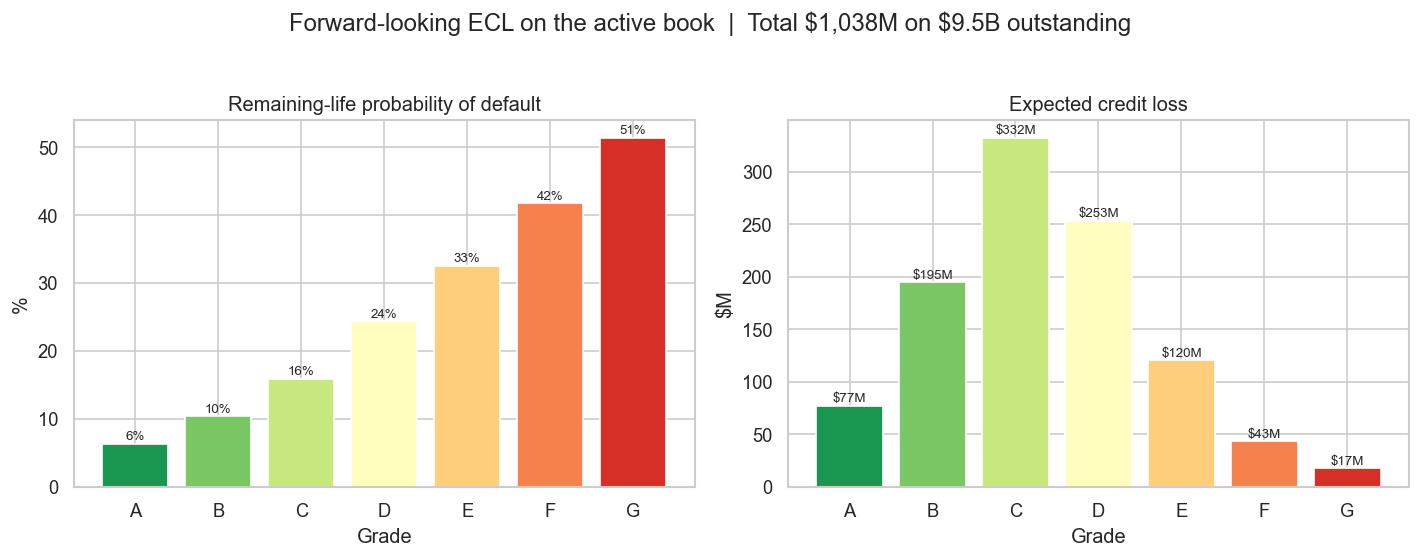

In [5]:
sc = ecl(active, cphd, cphp, LGD)
ecl_total = sc["ecl"].sum()
print(f"Current outstanding: ${exposure/1e9:.2f}B")
print(f"Expected credit loss: ${ecl_total/1e6:,.0f}M  ({ecl_total/exposure:.2%} of outstanding)")
print(f"Avg remaining-life PD {sc['rem_pd'].mean():.1%} | avg exposure-at-default ${sc['ead'].mean():,.0f}")

g = sc.groupby("grade").agg(ecl=("ecl","sum"), pd=("rem_pd","mean"))
print("\nECL by grade ($M):", {k:round(v/1e6) for k,v in g["ecl"].items()})

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
cols = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(g)))
ax[0].bar(g.index, g["pd"]*100, color=cols); ax[0].set_title("Remaining-life probability of default")
ax[0].set_ylabel("%"); ax[0].set_xlabel("Grade")
for i,v in enumerate(g["pd"]*100): ax[0].text(i, v+0.6, f"{v:.0f}%", ha="center", fontsize=8)
ax[1].bar(g.index, g["ecl"]/1e6, color=cols); ax[1].set_title("Expected credit loss")
ax[1].set_ylabel("$M"); ax[1].set_xlabel("Grade")
for i,v in enumerate(g["ecl"]/1e6): ax[1].text(i, v+4, f"${v:.0f}M", ha="center", fontsize=8)
plt.suptitle(f"Forward-looking ECL on the active book  |  Total \${ecl_total/1e6:,.0f}M on \${exposure/1e9:.1f}B outstanding", y=1.03)
plt.tight_layout(); plt.savefig("../output/figures/ecl_by_grade.png", dpi=150, bbox_inches="tight"); plt.show()

## A bad year is *systemic*, not random

With ~900k loans, individual-loan default randomness diversifies away almost
entirely; the reserve's real uncertainty is a downturn lifting everyone's default
rate at once, so we stress by scaling PD.

  Base           $1,038M (10.94% of outstanding)
  Mild +25%      $1,244M (13.10% of outstanding)
  Moderate +50%  $1,448M (15.26% of outstanding)
  Severe x2      $1,844M (19.44% of outstanding)
  Extreme x2.5   $2,214M (23.33% of outstanding)


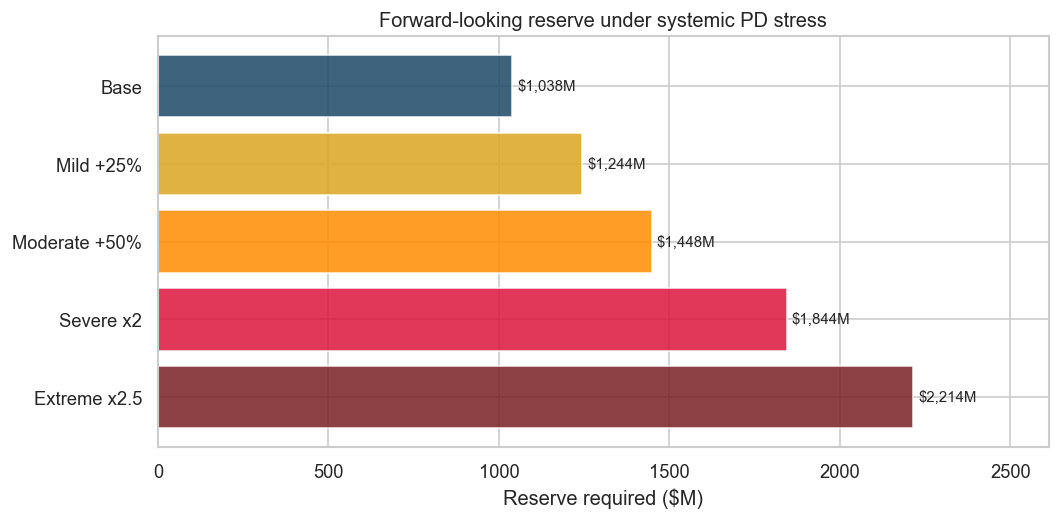

In [6]:
scen = [("Base",1.0),("Mild +25%",1.25),("Moderate +50%",1.5),("Severe x2",2.0),("Extreme x2.5",2.5)]
vals = [float((np.minimum(sc["rem_pd"]*k,1.0)*LGD*sc["ead"]).sum()) for _,k in scen]
for (lab,_),v in zip(scen, vals):
    print(f"  {lab:14s} ${v/1e6:,.0f}M ({v/exposure:.2%} of outstanding)")

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#1b4965","goldenrod","darkorange","crimson","#7a1f24"]
labels = [s for s,_ in scen]
bars = ax.barh(labels[::-1], [v/1e6 for v in vals][::-1], color=colors[::-1], alpha=0.85)
for b,v in zip(bars, vals[::-1]):
    ax.text(b.get_width()+15, b.get_y()+b.get_height()/2, f"${v/1e6:,.0f}M", va="center", fontsize=9)
ax.set_xlabel("Reserve required ($M)"); ax.set_xlim(0, max(vals)/1e6*1.18)
ax.set_title("Forward-looking reserve under systemic PD stress")
plt.tight_layout(); plt.savefig("../output/figures/ecl_stress.png", dpi=150); plt.show()

## Backtest — predicted vs realized loss by vintage

Train the hazard models **and** the LGD constant on loans issued ≤ 2014 only,
predict each vintage's lifetime loss rate from origination, and compare to realized
loss (principal owed at default, net of recoveries, as a share of original
principal). The shaded years are in-sample; the matured out-of-sample check is
2015–16. With prepayment modelled as a competing risk the calibration is roughly
centred on matured normal-condition years (the earlier single-risk version ran 2–4
points conservative). Residual misses run ±1 point both ways — the model carries no
vintage-quality effect, and the 2015–16 cohorts underperformed their observable
features. The 2007–08 crisis is under-predicted (no macro variable) and recent
vintages haven't matured.

backtest LGD (trained on ≤2014 outcomes): 0.874
            predicted  realized
issue_year                     
2007              6.3      19.1
2008              6.0      14.9
2009              5.4       8.8
2010              7.4       8.5
2011              9.3      10.2
2012              9.5      10.2
2013             10.2       9.2
2014             10.1      10.3
2015              9.5      11.2
2016              9.3      10.8
2017              9.6       7.2
2018              8.8       1.7


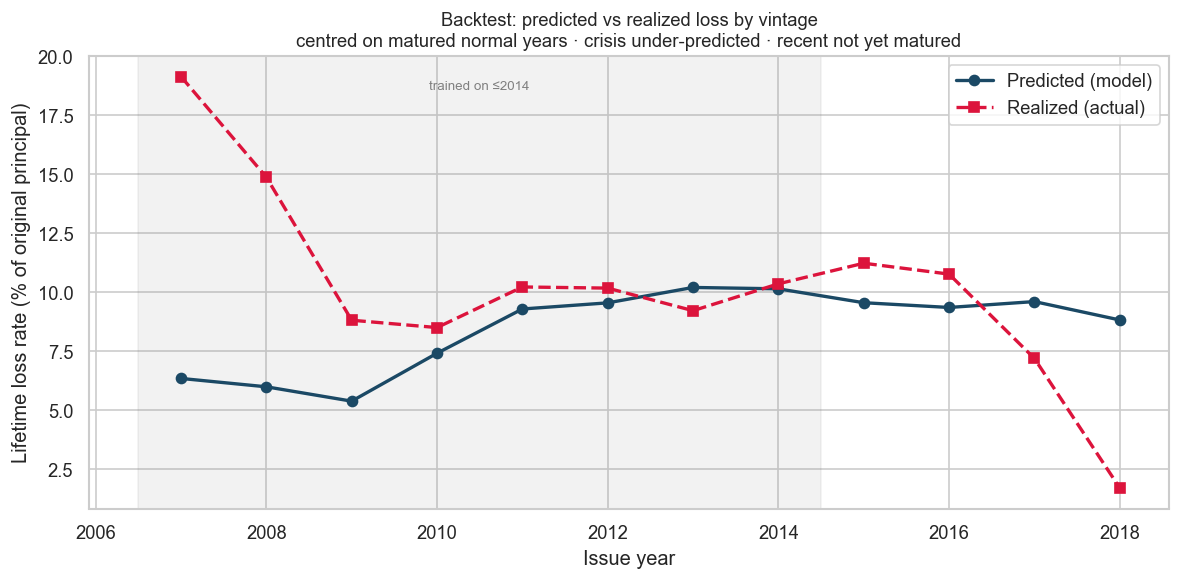

In [7]:
bt = df[df["issue_year"] <= 2014]
cphd_bt, cphp_bt = fit_hazards(bt)
LGD_bt = float(co.loc[co["issue_year"] <= 2014, "lgd_out"].mean())   # severity from the training window only
life = df.copy(); life["age0"] = 0.0; life["bal0"] = life["loan_amnt"]
life = ecl(life, cphd_bt, cphp_bt, LGD_bt, age_col="age0", bal_col="bal0", use_status=False)
life["realloss"] = np.where(life["loan_status"].isin(CHARGED),
    (life["loan_amnt"]-life["total_rec_prncp"]-life["recoveries"]).clip(lower=0), 0.0)
by = life.groupby("issue_year").apply(lambda d: pd.Series({
        "predicted": d["ecl"].sum()/d["loan_amnt"].sum()*100,
        "realized":  d["realloss"].sum()/d["loan_amnt"].sum()*100}), include_groups=False)
by.index = by.index.astype(int)
print(f"backtest LGD (trained on ≤2014 outcomes): {LGD_bt:.3f}")
print(by.round(1).to_string())

yrs = by.index.values
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yrs, by["predicted"], "o-", color="#1b4965", lw=2, label="Predicted (model)")
ax.plot(yrs, by["realized"], "s--", color="crimson", lw=2, label="Realized (actual)")
ax.axvspan(yrs.min()-0.5, 2014.5, color="gray", alpha=0.10)
ax.text(2010.5, ax.get_ylim()[1]*0.93, "trained on ≤2014", fontsize=8, color="gray", ha="center")
ax.set_xlabel("Issue year"); ax.set_ylabel("Lifetime loss rate (% of original principal)")
ax.set_title("Backtest: predicted vs realized loss by vintage\n"
             "centred on matured normal years · crisis under-predicted · recent not yet matured", fontsize=11)
ax.legend()
plt.tight_layout(); plt.savefig("../output/figures/ecl_backtest.png", dpi=150, bbox_inches="tight"); plt.show()

## Values baked into the dashboard

The interactive dashboard is parameterised from the output below — the per-grade
ECL at each downturn scenario, the constant LGD, the exposure, **and both
cause-specific hazard models** (coefficients, covariate means, baseline survival)
plus the active-book PD percentiles used for the benchmark. If the models are
refit, re-paste these values into `index.html` so the dashboard stays in exact
sync with the notebook.

In [8]:
gl = ["A","B","C","D","E","F","G"]
print(f"LGD = {LGD:.3f}  recovery = {1-LGD:.3f}")
print(f"current outstanding ($M): {exposure/1e6:.0f}")
print(f"per-grade outstanding ($M): {[round(active.groupby('grade')['out_prncp'].sum()[g]/1e6) for g in gl]}")
print(f"per-grade remaining PD: {[round(g_['rem_pd'].mean(),4) for _,g_ in sc.groupby('grade')]}")
for lab,k in scen:
    per = [round((np.minimum(sc.loc[sc['grade']==gg,'rem_pd']*k,1.0)*LGD*sc.loc[sc['grade']==gg,'ead']).sum()/1e6) for gg in gl]
    print(f"  {lab:14s} total ${sum(per)}M  per-grade {per}")

LGD = 0.891  recovery = 0.109
current outstanding ($M): 9489
per-grade outstanding ($M): [1999, 2671, 2841, 1364, 454, 120, 40]


per-grade remaining PD: [np.float64(0.0629), np.float64(0.1034), np.float64(0.159), np.float64(0.2434), np.float64(0.3252), np.float64(0.4176), np.float64(0.5138)]


  Base           total $1037M  per-grade [77, 195, 332, 253, 120, 43, 17]


  Mild +25%      total $1244M  per-grade [93, 233, 397, 304, 144, 52, 21]


  Moderate +50%  total $1449M  per-grade [110, 271, 461, 354, 168, 61, 24]


  Severe x2      total $1845M  per-grade [142, 347, 589, 455, 214, 71, 27]


  Extreme x2.5   total $2214M  per-grade [175, 423, 717, 555, 242, 74, 28]


In [9]:
# ── The hazard models themselves, for index.html (single source of truth) ───
# lifelines centres predict_partial_hazard on the training means, so the
# dashboard needs coefficients, means, and the baseline survival of BOTH
# cause-specific models (default and prepayment).
for name, c in [("COXD", cphd), ("COXP", cphp)]:
    print(f"{name}.coef  =", {k: float(v) for k, v in c.params_.items()})
    print(f"{name}.means =", {k: float(c._norm_mean[k]) for k in SF})
    bsv = c.baseline_survival_["baseline survival"]
    print(f"{name}.base  =", [[m, round(float(np.interp(m, bsv.index.values, bsv.values)), 5)]
                              for m in range(0, 61)])
print("REM_PD_PCT =", [round(float(p), 4)
                       for p in np.percentile(sc["rem_pd"], np.arange(0, 101, 5))])

COXD.coef  = {'int_rate': 7.705776883155778, 'dti': 0.001529026327581638, 'fico': -0.0028990155000504316, 'annual_inc': -1.010828915096618e-06, 'grade_num': 0.12058509774161612, 'term': -0.005068520405475906}
COXD.means = {'int_rate': 0.13088154866666665, 'dti': 18.884755799999997, 'fico': 700.5909433333334, 'annual_inc': 78031.4488374, 'grade_num': 2.663473333333333, 'term': 42.89744}
COXD.base  = [[0, 1.0], [1, 0.99858], [2, 0.99684], [3, 0.99531], [4, 0.99237], [5, 0.98823], [6, 0.98386], [7, 0.97513], [8, 0.97023], [9, 0.9648], [10, 0.95877], [11, 0.9535], [12, 0.94433], [13, 0.94251], [14, 0.93589], [15, 0.92955], [16, 0.92006], [17, 0.91416], [18, 0.90753], [19, 0.90149], [20, 0.89593], [21, 0.88639], [22, 0.88023], [23, 0.8739], [24, 0.86892], [25, 0.86374], [26, 0.85713], [27, 0.85116], [28, 0.84548], [29, 0.83965], [30, 0.83176], [31, 0.82608], [32, 0.82111], [33, 0.81624], [34, 0.81117], [35, 0.80383], [36, 0.79956], [37, 0.79647], [38, 0.79212], [39, 0.78643], [40, 0.77991],